#### Statistical Significance of A/B Test Uplifts

**Objective**  
Add proper statistical validation to the observed differences between Variant A and B.

**Main tests used**  
- **Proportion test** / **z-test** for binary metrics (retention D1/D7/D30, payer conversion)  
- **Independent t-test** (Welch's) for continuous metrics (revenue, sessions, levels)  
- Confidence intervals for differences / relative uplifts

**Data source**  
fact_user_metrics table (user-level data)

#### 1. Imports

In [1]:
import duckdb
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.weightstats import ttest_ind
import plotly.express as px

con = duckdb.connect(':memory:')

# Load user-level data
con.execute("""
    CREATE OR REPLACE TABLE fact AS
    SELECT * FROM read_parquet('../data/processed_data/fact_user_metrics.parquet')
""")

print("Loaded fact_user_metrics")
print(con.sql("SELECT variant, COUNT(*) FROM fact GROUP BY variant").df())

Loaded fact_user_metrics
  variant  count_star()
0       A         49934
1       B         50066


#### Helper functions for significance testing

In [2]:
def test_proportion(a_success, a_total, b_success, b_total, metric_name):
    """
    Two-proportion z-test + confidence interval for difference
    """
    count = np.array([a_success, b_success])
    nobs = np.array([a_total, b_total])
    
    stat, pval = proportions_ztest(count, nobs, alternative='two-sided')
    diff = (b_success / b_total) - (a_success / a_total)
    
    # 95% CI for difference
    ci_low, ci_high = proportion_confint(b_success, b_total, alpha=0.05, method='wilson') - \
                      proportion_confint(a_success, a_total, alpha=0.05, method='wilson')
    
    return {
        'metric': metric_name,
        'A_rate': a_success / a_total,
        'B_rate': b_success / b_total,
        'absolute_diff': diff,
        'relative_uplift_%': (diff / (a_success / a_total)) * 100 if a_success > 0 else np.nan,
        'z_stat': stat,
        'p_value': pval,
        'ci_diff_95_low': ci_low,
        'ci_diff_95_high': ci_high
    }


def test_ttest(a_values, b_values, metric_name):
    """
    Welch's t-test for means + 95% CI for difference
    """
    t_stat, p_val, df = ttest_ind(a_values, b_values, alternative='two-sided', usevar='unequal')
    
    mean_diff = np.mean(b_values) - np.mean(a_values)
    se_diff = np.sqrt(np.var(a_values)/len(a_values) + np.var(b_values)/len(b_values))
    ci_low = mean_diff - 1.96 * se_diff
    ci_high = mean_diff + 1.96 * se_diff
    
    return {
        'metric': metric_name,
        'A_mean': np.mean(a_values),
        'B_mean': np.mean(b_values),
        'mean_diff': mean_diff,
        'relative_uplift_%': (mean_diff / np.mean(a_values)) * 100 if np.mean(a_values) != 0 else np.nan,
        't_stat': t_stat,
        'p_value': p_val,
        'ci_diff_95_low': ci_low,
        'ci_diff_95_high': ci_high
    }

#### Overall significance – binary metrics (retention & payer)


In [4]:
def test_proportion(a_success, a_total, b_success, b_total, metric_name):
    """
    Two-proportion z-test + confidence interval for difference
    """
    import numpy as np
    from statsmodels.stats.proportion import proportions_ztest, proportion_confint
    
    count = np.array([a_success, b_success])
    nobs = np.array([a_total, b_total])
    
    # z-test for difference in proportions
    z_stat, pval = proportions_ztest(count, nobs, alternative='two-sided')
    
    # Rates
    rate_a = a_success / a_total if a_total > 0 else 0
    rate_b = b_success / b_total if b_total > 0 else 0
    absolute_diff = rate_b - rate_a
    relative_uplift = (absolute_diff / rate_a * 100) if rate_a > 0 else np.nan
    
    # 95% CI for each proportion (Wilson score)
    ci_a = proportion_confint(a_success, a_total, alpha=0.05, method='wilson')
    ci_b = proportion_confint(b_success, b_total, alpha=0.05, method='wilson')
    
    # Approximate 95% CI for the difference (simple subtraction)
    # Note: this is conservative; for more precise CI use pooled variance or bootstrap
    ci_diff_low  = (ci_b[0] - ci_a[1])
    ci_diff_high = (ci_b[1] - ci_a[0])
    
    return {
        'metric': metric_name,
        'A_rate': round(rate_a, 4),
        'B_rate': round(rate_b, 4),
        'absolute_diff': round(absolute_diff, 4),
        'relative_uplift_%': round(relative_uplift, 1),
        'z_stat': round(z_stat, 3),
        'p_value': round(pval, 6),
        'ci_diff_95_low': round(ci_diff_low, 4),
        'ci_diff_95_high': round(ci_diff_high, 4)
    }

#### Overall significance – continuous metrics (revenue, sessions, levels)


In [5]:
continuous_results = []

for col in ['revenue', 'sessions_d1', 'levels_d7']:
    a_vals = con.sql(f"SELECT {col} FROM fact WHERE variant = 'A'").df()[col].values
    b_vals = con.sql(f"SELECT {col} FROM fact WHERE variant = 'B'").df()[col].values
    
    continuous_results.append(test_ttest(a_vals, b_vals, col))

df_continuous = pd.DataFrame(continuous_results)
df_continuous['significant_5pct'] = df_continuous['p_value'] < 0.05

print("Continuous metrics significance (overall)")
display(df_continuous.round(4))

Continuous metrics significance (overall)


,metric,A_mean,B_mean,mean_diff,relative_uplift_%,t_stat,p_value,ci_diff_95_low,ci_diff_95_high,significant_5pct
0,revenue,0.4962,0.5769,0.0806,16.2490,-23.6739,0.0,0.0740,0.0873,True
1,sessions_d1,2.6766,3.1096,0.4330,16.1781,-42.9279,0.0,0.4133,0.4528,True
2,levels_d7,14.9861,18.5790,3.5929,23.9746,-138.5998,0.0,3.5420,3.6437,True


#### Per-cohort significance example (D7 retention) – last ~90 days

In [10]:
con.execute("""
    CREATE OR REPLACE TABLE cohort_daily AS
    SELECT * FROM read_parquet('../data/processed_data/cohort_daily.parquet')
""")

print("cohort_daily reloaded from Parquet")
print("Sample:")
display(con.sql("SELECT * FROM cohort_daily LIMIT 3").df())

cohort_daily reloaded from Parquet
Sample:


,install_day,variant,cohort_size,retention_d1_pct,retention_d7_pct,retention_d30_pct,avg_revenue,avg_sessions_d1,avg_levels_d7,payer_conversion_pct
0,2023-04-01,A,55,38.18,38.18,7.27,0.436,2.62,15.62,0.0
1,2023-04-01,B,50,56.00,30.00,12.00,0.693,3.04,18.60,2.0
2,2023-04-02,A,47,19.15,19.15,6.38,0.503,2.94,16.51,0.0


In [11]:
cohort_results = []

# Load recent data 
recent_cohorts = con.sql("""
    SELECT 
        install_day, 
        variant, 
        retention_d7_pct, 
        cohort_size
    FROM cohort_daily
    WHERE install_day >= '2025-08-01'
      AND install_day <= '2025-10-30'
    ORDER BY install_day DESC, variant
""").df()

print(f"Loaded {len(recent_cohorts)} rows | {recent_cohorts['install_day'].nunique()} unique days")

if recent_cohorts.empty:
    print("No data in range.")
else:
    days = sorted(recent_cohorts['install_day'].unique(), reverse=True)  # newest first

    for day in days:
        day_data = recent_cohorts[recent_cohorts['install_day'] == day]
        if len(day_data) != 2:
            continue  # skip incomplete days
        
        a_row = day_data[day_data['variant'] == 'A'].iloc[0]
        b_row = day_data[day_data['variant'] == 'B'].iloc[0]
        
        # Approximate successes
        a_success = round(a_row['retention_d7_pct'] / 100 * a_row['cohort_size'])
        b_success = round(b_row['retention_d7_pct'] / 100 * b_row['cohort_size'])
        
        # Run test
        res = test_proportion(
            int(a_success), int(a_row['cohort_size']),
            int(b_success), int(b_row['cohort_size']),
            'D7 retention'
        )
        
        # Add the date to the result dictionary
        res['install_day'] = day
        
        cohort_results.append(res)

if cohort_results:
    df_cohort_sig = pd.DataFrame(cohort_results)
    
    # Add significance flag
    df_cohort_sig['significant_5pct'] = df_cohort_sig['p_value'] < 0.05
    
    # Sort by date (newest first)
    df_cohort_sig = df_cohort_sig.sort_values('install_day', ascending=False)
    
    # Reorder columns for better readability
    cols = ['install_day', 'metric', 'A_rate', 'B_rate', 'absolute_diff', 
            'relative_uplift_%', 'z_stat', 'p_value', 'significant_5pct',
            'ci_diff_95_low', 'ci_diff_95_high']
    df_cohort_sig = df_cohort_sig[[c for c in cols if c in df_cohort_sig.columns]]
    
    print("Per-cohort statistical significance – D7 retention (Aug–Oct 2025)")
    display(df_cohort_sig.round(4))
    
    # Optional: Quick summary
    print(f"\nSignificant days (p < 0.05): {df_cohort_sig['significant_5pct'].sum()} / {len(df_cohort_sig)}")
else:
    print("No complete A+B cohort pairs found in the period.")

Loaded 182 rows | 91 unique days
Per-cohort statistical significance – D7 retention (Aug–Oct 2025)


,install_day,metric,A_rate,B_rate,absolute_diff,relative_uplift_%,z_stat,p_value,significant_5pct,ci_diff_95_low,ci_diff_95_high
0,2025-10-30,D7 retention,0.3051,0.2041,-0.1010,-33.1,1.192,0.2331,False,-0.3166,0.1338
1,2025-10-29,D7 retention,0.1639,0.2742,0.1103,67.3,-1.477,0.1396,False,-0.0973,0.3044
2,2025-10-28,D7 retention,0.2258,0.3261,0.1003,44.4,-1.163,0.2449,False,-0.1354,0.3308
3,2025-10-27,D7 retention,0.1923,0.3043,0.1120,58.3,-1.287,0.1980,False,-0.1282,0.3401
4,2025-10-26,D7 retention,0.1852,0.3188,0.1337,72.2,-1.677,0.0936,False,-0.0874,0.3320
...,...,...,...,...,...,...,...,...,...,...,...
86,2025-08-05,D7 retention,0.2031,0.2340,0.0309,15.2,-0.391,0.6958,False,-0.1811,0.2495
87,2025-08-04,D7 retention,0.2333,0.3167,0.0833,35.7,-1.022,0.3067,False,-0.1413,0.2979
88,2025-08-03,D7 retention,0.3143,0.3519,0.0376,12.0,-0.366,0.7142,False,-0.2416,0.2996
89,2025-08-02,D7 retention,0.3148,0.3214,0.0066,2.1,-0.074,0.9407,False,-0.2334,0.2450



Significant days (p < 0.05): 14 / 91


#### Summary – p-values across metrics


In [13]:
print("Checking if df_binary & df_continuous exist...")

try:
    print("df_binary exists → rows:", len(df_binary))
except NameError:
    print("df_binary not found → re-running Cell 3 logic")
    # Re-run the binary metrics part 
    results = []
    for col in ['d1_retention', 'd7_retention', 'd30_retention', 'is_payer']:
        a = con.sql(f"SELECT {col} FROM fact WHERE variant = 'A'").df()[col]
        b = con.sql(f"SELECT {col} FROM fact WHERE variant = 'B'").df()[col]
        
        a_success = a.sum()
        a_total   = len(a)
        b_success = b.sum()
        b_total   = len(b)
        
        results.append(test_proportion(a_success, a_total, b_success, b_total, col))
    
    df_binary = pd.DataFrame(results)
    df_binary['significant_5pct'] = df_binary['p_value'] < 0.05

try:
    print("df_continuous exists → rows:", len(df_continuous))
except NameError:
    print("df_continuous not found → re-running Cell 4 logic")
    # Re-run continuous metrics
    continuous_results = []
    for col in ['revenue', 'sessions_d1', 'levels_d7']:
        a_vals = con.sql(f"SELECT {col} FROM fact WHERE variant = 'A'").df()[col].values
        b_vals = con.sql(f"SELECT {col} FROM fact WHERE variant = 'B'").df()[col].values
        continuous_results.append(test_ttest(a_vals, b_vals, col))
    
    df_continuous = pd.DataFrame(continuous_results)
    df_continuous['significant_5pct'] = df_continuous['p_value'] < 0.05

# Now combine them safely
df_all = pd.concat([
    df_binary[['metric', 'p_value', 'significant_5pct']],
    df_continuous[['metric', 'p_value', 'significant_5pct']]
], ignore_index=True)

df_all['-log10_p'] = -np.log10(df_all['p_value'].clip(1e-10))

print("\nCombined data ready for plotting – rows:", len(df_all))
display(df_all.sort_values('p_value').round(6))

Checking if df_binary & df_continuous exist...
df_binary not found → re-running Cell 3 logic
df_continuous exists → rows: 3

Combined data ready for plotting – rows: 7


,metric,p_value,significant_5pct,-log10_p
0,d1_retention,0.0,True,10.0
1,d7_retention,0.0,True,10.0
2,d30_retention,0.0,True,10.0
3,is_payer,0.0,True,10.0
5,sessions_d1,0.0,True,10.0
6,levels_d7,0.0,True,10.0
4,revenue,0.0,True,10.0


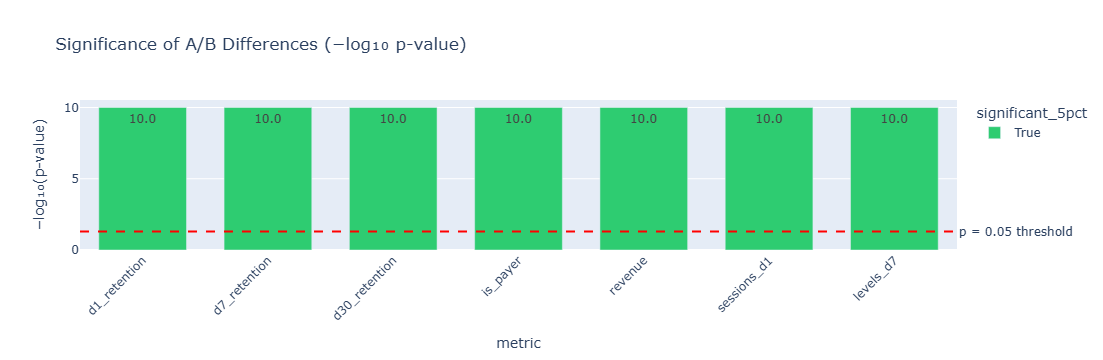

In [14]:
df_all['-log10_p'] = -np.log10(df_all['p_value'].clip(1e-10))

fig = px.bar(
    df_all.sort_values('-log10_p', ascending=False),
    x='metric',
    y='-log10_p',
    color='significant_5pct',
    title='Significance of A/B Differences (−log₁₀ p-value)',
    text_auto='.1f',
    labels={'-log10_p': '−log₁₀(p-value) — higher = stronger evidence'},
    color_discrete_map={True: '#2ecc71', False: '#e74c3c'}
)

fig.add_hline(y=-np.log10(0.05), line_dash="dash", line_color="red",
              annotation_text="p = 0.05 threshold", annotation_position="right")

fig.update_layout(
    height=550,
    xaxis_tickangle=-45,
    yaxis_title="−log₁₀(p-value)",
    bargap=0.3
)

fig.show()